# 02 -- Frozen Mantis+ и robustness

Основной эксперимент ДЗ:

- `MantisV1` + `paris-noah/MantisPlus`;
- encoder полностью frozen;
- поверх признаков -- `StandardScaler + LogisticRegression`;
- проверяю **все 6 существующих Transformer layers**;
- дополнительно сравниваю устойчивость слоев к block corruption.

У MantisV1 физически 6 Transformer blocks, поэтому больше layer indices без смены backbone нет. Вместо искусственного «добавления слоев» сравниваю каждый слой сразу в нескольких режимах качества входа.

In [15]:
from pathlib import Path
from time import perf_counter
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report

from mantis.architecture import MantisV1
from mantis.trainer import MantisTrainer

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
FIG = ROOT / 'figures'

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

CHECKPOINT = 'paris-noah/MantisPlus'
LAYERS = list(range(6))

print('device:', DEVICE)
print('checkpoint:', CHECKPOINT)
print(platform.platform())


device: mps
checkpoint: paris-noah/MantisPlus
macOS-26.6.2-arm64-arm-64bit-Mach-O


In [16]:
data = np.load(DATA / 'uci_har_raw.npz')
split = np.load(DATA / 'split.npz')

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
train_idx, val_idx = split['train_idx'], split['val_idx']

X_fit, y_fit = X_train[train_idx], y_train[train_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

CORRUPTION_LEVELS = [0.0, 0.20, 0.35, 0.50]
CORRUPT_CHANNELS = 4


def resize(X, length):
    x = torch.tensor(X, dtype=torch.float32)
    if X.shape[-1] != length:
        x = F.interpolate(x, size=length, mode='linear', align_corners=False)
    return x.numpy()


def block_corrupt(X, fraction, n_channels=CORRUPT_CHANNELS, seed=1000 + 42):
    Xc = X.copy()
    if fraction == 0:
        return Xc

    rng = np.random.default_rng(seed)
    _, channels, length = Xc.shape
    width = max(1, int(round(length * fraction)))

    for i in range(len(Xc)):
        selected = rng.choice(channels, size=n_channels, replace=False)
        center = int(rng.integers(0, length))
        start = min(max(center - width // 2, 0), length - width)
        observed = np.ones(length, dtype=bool)
        observed[start:start + width] = False

        for ch in selected:
            fill = Xc[i, ch, observed].mean()
            Xc[i, ch, start:start + width] = fill

    return Xc


X_fit_512 = resize(X_fit, 512)
X_val_stress_512 = {
    level: resize(block_corrupt(X_val, level), 512)
    for level in CORRUPTION_LEVELS
}

print(X_fit.shape, '->', X_fit_512.shape)
print('stress levels:', CORRUPTION_LEVELS)

(5551, 9, 128) -> (5551, 9, 512)
stress levels: [0.0, 0.2, 0.35, 0.5]


## Сравнение слоев: clean + stress-test

Сравниваю все `6` Transformer layers MantisV1. Для каждого слоя Logistic Regression обучается **один раз на clean fit features**, после чего тот же classifier проверяется на clean validation и на `20/35/50%` block corruption.

Итоговый `selection_f1` -- средний validation macro F1 по четырем заранее заданным режимам. Так слой выбирается не только по «идеальному» входу, но и по устойчивости. Test здесь не используется.

In [17]:
def extractor(layer):
    network = MantisV1(
        device=DEVICE,
        return_transf_layer=layer,
        output_token='combined',
    )
    network = network.from_pretrained(CHECKPOINT)
    return MantisTrainer(device=DEVICE, network=network)


def classifier():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1500, C=1.0, solver='lbfgs')
    )


def metrics(y, pred):
    return {
        'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'macro_f1': f1_score(y, pred, average='macro'),
    }


In [18]:
layer_stress_rows = []
layer_rows = []
features_512 = {}

for layer in LAYERS:
    model = extractor(layer)

    t0 = perf_counter()
    Z_fit = np.asarray(model.transform(X_fit_512))
    Z_val_by_level = {
        level: np.asarray(model.transform(Xv))
        for level, Xv in X_val_stress_512.items()
    }
    extract_s = perf_counter() - t0

    clf = classifier()
    t0 = perf_counter()
    clf.fit(Z_fit, y_fit)
    fit_s = perf_counter() - t0

    scores = {}
    for level, Z_val in Z_val_by_level.items():
        pred = clf.predict(Z_val)
        m = metrics(y_val, pred)
        scores[level] = m['macro_f1']
        layer_stress_rows.append({
            'layer': layer,
            'corruption': level,
            **m,
        })

    clean_f1 = scores[0.0]
    robust_mean = np.mean([scores[x] for x in CORRUPTION_LEVELS if x > 0])
    selection_f1 = np.mean(list(scores.values()))

    layer_rows.append({
        'layer': layer,
        'feature_dim': Z_fit.shape[1],
        'extract_fit_val_s': extract_s,
        'classifier_fit_s': fit_s,
        'clean_macro_f1': clean_f1,
        'robust_mean_f1': robust_mean,
        'selection_f1': selection_f1,
    })
    features_512[layer] = (Z_fit, Z_val_by_level[0.0])
    print(
        f"layer={layer}  clean={clean_f1:.4f}  "
        f"robust_mean={robust_mean:.4f}  selection={selection_f1:.4f}"
    )

layer_results = pd.DataFrame(layer_rows)
layer_stress = pd.DataFrame(layer_stress_rows)
layer_results.to_csv(RESULTS / '02_mantis_layers.csv', index=False)
layer_stress.to_csv(RESULTS / '02_mantis_layer_stress.csv', index=False)
layer_results

layer=0  clean=0.9718  robust_mean=0.9602  selection=0.9631
layer=1  clean=0.9648  robust_mean=0.9467  selection=0.9513
layer=2  clean=0.9716  robust_mean=0.9479  selection=0.9539
layer=3  clean=0.9706  robust_mean=0.9498  selection=0.9550
layer=4  clean=0.9678  robust_mean=0.9423  selection=0.9487
layer=5  clean=0.9693  robust_mean=0.9388  selection=0.9464


,layer,feature_dim,extract_fit_val_s,classifier_fit_s,clean_macro_f1,robust_mean_f1,selection_f1
0,0,4608,12.916397,0.563229,0.971811,0.960175,0.963084
1,1,4608,16.213440,0.384854,0.964831,0.946738,0.951261
2,2,4608,20.488474,0.645741,0.971613,0.947948,0.953865
3,3,4608,24.447078,0.483870,0.970589,0.949790,0.954990
4,4,4608,26.025301,0.510967,0.967774,0.942335,0.948695
5,5,4608,32.430983,0.505028,0.969289,0.938831,0.946446


best clean layer: 0
best robust-selection layer: 0


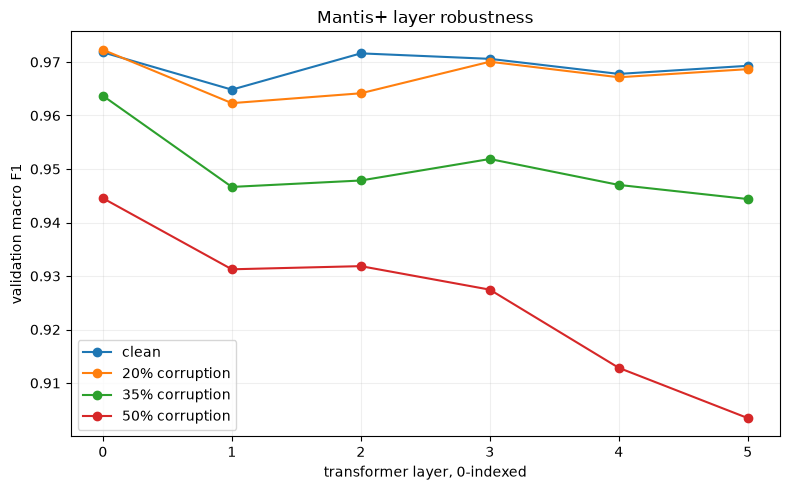

F1 spread between layers:
clean: 0.0070
20%: 0.0100
35%: 0.0193
50%: 0.0411


In [19]:
best_clean_layer = int(layer_results.loc[layer_results.clean_macro_f1.idxmax(), 'layer'])
best_layer = int(layer_results.loc[layer_results.selection_f1.idxmax(), 'layer'])
print('best clean layer:', best_clean_layer)
print('best robust-selection layer:', best_layer)

fig, ax = plt.subplots(figsize=(8, 5))
for level in CORRUPTION_LEVELS:
    part = layer_stress[layer_stress.corruption == level]
    label = 'clean' if level == 0 else f'{int(level * 100)}% corruption'
    ax.plot(part.layer, part.macro_f1, marker='o', label=label)
ax.set_xticks(LAYERS)
ax.set_xlabel('transformer layer, 0-indexed')
ax.set_ylabel('validation macro F1')
ax.set_title('Mantis+ layer robustness')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG / '02_layer_comparison.png', dpi=160)
plt.show()

spread = layer_stress.groupby('corruption').macro_f1.agg(lambda x: x.max() - x.min())
print('F1 spread between layers:')
for level, value in spread.items():
    name = 'clean' if level == 0 else f'{int(level*100)}%'
    print(f'{name}: {value:.4f}')

### Интерпретация layer probing

На clean validation слои почти насыщены: разброс между лучшим и худшим всего **0.0070 macro F1**. Но по мере corruption различия быстро растут: `0.0100` при 20%, `0.0193` при 35% и уже **0.0411** при 50%.

Лучшим и на clean, и по robustness-критерию оказался **layer 0**. При 50% corruption он дает `0.9445`, тогда как layer 5 -- `0.9034`. Значит, в этой задаче более глубокий representation не становится автоматически более transferable: ранний слой лучше сохраняет полезные признаки при сдвиге входного распределения.

Это именно эмпирический вывод для UCI HAR. По одному корпусу нельзя утверждать, что глубокие слои Mantis *всегда* менее устойчивы; зато stress-test показывает, зачем layer selection вообще нужен -- на clean различия были бы почти незаметны.


## Ablation -- temporal scales

На выбранном robust-layer сравниваю `128`, `512` и `128+512` уже в двух режимах:

- clean validation;
- `35%` block corruption.

Для выбора scale использую среднее этих двух macro F1. Это по-прежнему validation-only selection.

In [20]:
scale_extractor = extractor(best_layer)

scale_t0 = perf_counter()
Z_fit_512, Z_val_512 = features_512[best_layer]
X_val_35 = block_corrupt(X_val, 0.35)

# clean features at scale 128
Z_fit_128 = np.asarray(scale_extractor.transform(X_fit))
Z_val_128 = np.asarray(scale_extractor.transform(X_val))

# corrupted validation features
Z_val_128_corrupt = np.asarray(scale_extractor.transform(X_val_35))
Z_val_512_corrupt = np.asarray(scale_extractor.transform(resize(X_val_35, 512)))
scale_extract_s = perf_counter() - scale_t0

scale_features = {
    '128': (
        Z_fit_128,
        Z_val_128,
        Z_val_128_corrupt,
    ),
    '512': (
        Z_fit_512,
        Z_val_512,
        Z_val_512_corrupt,
    ),
    '128+512': (
        np.concatenate([Z_fit_128, Z_fit_512], axis=1),
        np.concatenate([Z_val_128, Z_val_512], axis=1),
        np.concatenate([Z_val_128_corrupt, Z_val_512_corrupt], axis=1),
    ),
}

ablation_rows = []
for name, (zf, zv_clean, zv_corrupt) in scale_features.items():
    clf = classifier()
    t0 = perf_counter()
    clf.fit(zf, y_fit)
    fit_s = perf_counter() - t0

    clean = metrics(y_val, clf.predict(zv_clean))
    corrupt = metrics(y_val, clf.predict(zv_corrupt))
    selection_f1 = 0.5 * (clean['macro_f1'] + corrupt['macro_f1'])

    ablation_rows.append({
        'scale': name,
        'feature_dim': zf.shape[1],
        'classifier_fit_s': fit_s,
        'clean_macro_f1': clean['macro_f1'],
        'corrupt35_macro_f1': corrupt['macro_f1'],
        'selection_f1': selection_f1,
    })

ablation = pd.DataFrame(ablation_rows)
best_scale = ablation.loc[ablation.selection_f1.idxmax(), 'scale']
ablation.to_csv(RESULTS / '02_mantis_ablation.csv', index=False)
print('best scale:', best_scale)
ablation

best scale: 128+512


,scale,feature_dim,classifier_fit_s,clean_macro_f1,corrupt35_macro_f1,selection_f1
0,128,4608,0.565279,0.974601,0.961743,0.968172
1,512,4608,0.578621,0.971811,0.963693,0.967752
2,128+512,9216,0.876766,0.977722,0.959171,0.968447


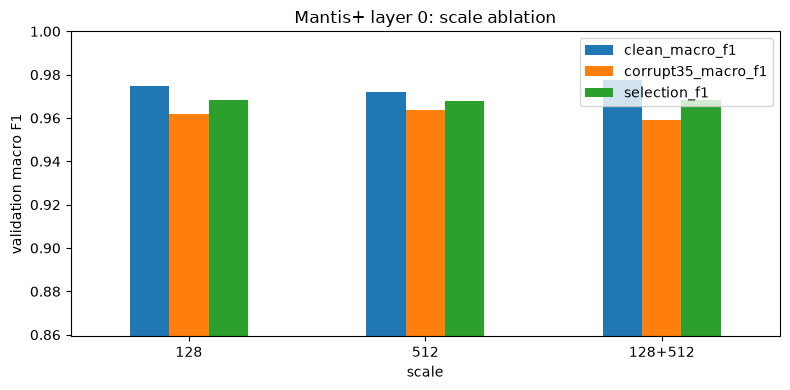

In [21]:
ax = ablation.set_index('scale')[['clean_macro_f1', 'corrupt35_macro_f1', 'selection_f1']].plot(
    kind='bar', figsize=(8, 4), rot=0
)
ax.set_ylim(max(0, ablation[['clean_macro_f1','corrupt35_macro_f1']].min().min() - 0.10), 1.0)
ax.set_ylabel('validation macro F1')
ax.set_title(f'Mantis+ layer {best_layer}: scale ablation')
plt.tight_layout()
plt.savefig(FIG / '02_ablation.png', dpi=160)
plt.show()

### Интерпретация абляции

На clean validation лучший результат дает `128+512`: **0.9777 macro F1**. Но при 35% corruption картина меняется: лучший single scale -- `512` с **0.9637**, а `128+512` падает до `0.9592`.

По заранее заданному среднему критерию формально побеждает `128+512` (`0.96845`), но `128` получает `0.96817`, а `512` -- `0.96775`. Разница меньше **0.0007 F1**, то есть практически все три варианта сопоставимы по selection score.

Поэтому multi-scale здесь полезен скорее как способ выжать максимум clean quality, а не как убедительный robustness-win. Он удваивает feature dimension `4608 -> 9216`, поэтому при ограничениях на память/latency single-scale вариант выглядел бы рациональнее. Это хороший пример того, что формальный победитель абляции не обязательно является лучшим инженерным компромиссом.


## Финальная frozen Mantis

После выбора `layer` и `scale` по validation извлекаю признаки для всего official train, обучаю один linear classifier и только теперь считаю official test.


In [22]:
def transform_scale(model, X, scale):
    if scale == '128':
        return np.asarray(model.transform(X))
    if scale == '512':
        return np.asarray(model.transform(resize(X, 512)))
    z128 = np.asarray(model.transform(X))
    z512 = np.asarray(model.transform(resize(X, 512)))
    return np.concatenate([z128, z512], axis=1)

final_extractor = extractor(best_layer)

t0 = perf_counter()
Z_train = transform_scale(final_extractor, X_train, best_scale)
train_extract_s = perf_counter() - t0

t0 = perf_counter()
Z_test = transform_scale(final_extractor, X_test, best_scale)
test_extract_s = perf_counter() - t0

final_clf = classifier()
t0 = perf_counter()
final_clf.fit(Z_train, y_train)
classifier_fit_s = perf_counter() - t0

t0 = perf_counter()
pred_test = final_clf.predict(Z_test)
classifier_predict_s = perf_counter() - t0

mantis_metrics = metrics(y_test, pred_test)
latency_ms = 1000 * (test_extract_s + classifier_predict_s) / len(y_test)
selection_time = float(layer_results.extract_fit_val_s.sum() + layer_results.classifier_fit_s.sum() + scale_extract_s + ablation.classifier_fit_s.sum())

mantis = {
    'model': 'Mantis+ frozen',
    'checkpoint': CHECKPOINT,
    'best_layer': best_layer,
    'best_scale': best_scale,
    'feature_dim': int(Z_train.shape[1]),
    'selection_time_s': selection_time,
    'train_time_s': float(train_extract_s + classifier_fit_s),
    'latency_ms_sample': float(latency_ms),
    **{k: float(v) for k, v in mantis_metrics.items()},
}
with open(RESULTS / '02_mantis_metrics.json', 'w') as f:
    json.dump(mantis, f, indent=2)

pd.DataFrame(classification_report(y_test, pred_test, output_dict=True)).T.to_csv(
    RESULTS / '02_mantis_class_report.csv'
)

mantis


{'model': 'Mantis+ frozen',
 'checkpoint': 'paris-noah/MantisPlus',
 'best_layer': 0,
 'best_scale': '128+512',
 'feature_dim': 9216,
 'selection_time_s': 146.38790558313485,
 'train_time_s': 13.624983875022735,
 'latency_ms_sample': 1.6975417515886477,
 'accuracy': 0.9776043434000679,
 'balanced_accuracy': 0.9772481911014212,
 'macro_f1': 0.9778026714406763}

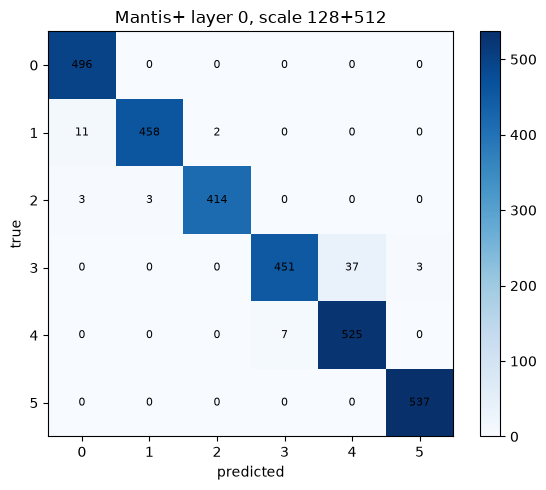

In [23]:
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'Mantis+ layer {best_layer}, scale {best_scale}')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG / '02_mantis_confusion.png', dpi=160)
plt.show()


### Что изменилось по классам

Mantis улучшает не только среднее качество. Наиболее заметный прирост относительно Transformer приходится на трудные классы:

- `SITTING`: `0.8478 -> 0.9505` F1;
- `STANDING`: `0.8836 -> 0.9598`;
- `WALKING_DOWNSTAIRS`: `0.9048 -> 0.9904`.

Для `LAYING` выигрыш почти отсутствует (`0.9954 -> 0.9972`), потому что baseline уже почти решает этот класс идеально. То есть pretrained features в основном помогают там, где простому supervised Transformer не хватает межсубъектно устойчивого representation.


## Robustness: Mantis vs Transformer

Финальная Mantis-конфигурация уже выбрана только по validation. Теперь фиксирую ее и, как для baseline, измеряю test macro F1 при `0/20/35/50%` block corruption без какого-либо переобучения.

In [24]:
mantis_robust_rows = []
for fraction in CORRUPTION_LEVELS:
    if fraction == 0:
        m = mantis_metrics
    else:
        Xc = block_corrupt(X_test, fraction)
        Zc = transform_scale(final_extractor, Xc, best_scale)
        m = metrics(y_test, final_clf.predict(Zc))
    mantis_robust_rows.append({'corruption': fraction, **m})

mantis_robustness = pd.DataFrame(mantis_robust_rows)
mantis_robustness.to_csv(RESULTS / '02_mantis_robustness.csv', index=False)

transformer_robustness = pd.read_csv(RESULTS / '01_transformer_robustness.csv')
robustness = pd.concat([
    transformer_robustness.assign(model='Transformer'),
    mantis_robustness.assign(model='Mantis+ frozen'),
], ignore_index=True)
robustness.to_csv(RESULTS / 'robustness_comparison.csv', index=False)
robustness

,corruption,accuracy,balanced_accuracy,macro_f1,model
0,0.00,0.914829,0.915210,0.913672,Transformer
1,0.20,0.909399,0.909154,0.908001,Transformer
2,0.35,0.901256,0.900072,0.899438,Transformer
3,0.50,0.887343,0.884818,0.884819,Transformer
4,0.00,0.977604,0.977248,0.977803,Mantis+ frozen
5,0.20,0.970478,0.969919,0.970490,Mantis+ frozen
6,0.35,0.954869,0.953791,0.954253,Mantis+ frozen
7,0.50,0.927723,0.926042,0.925953,Mantis+ frozen


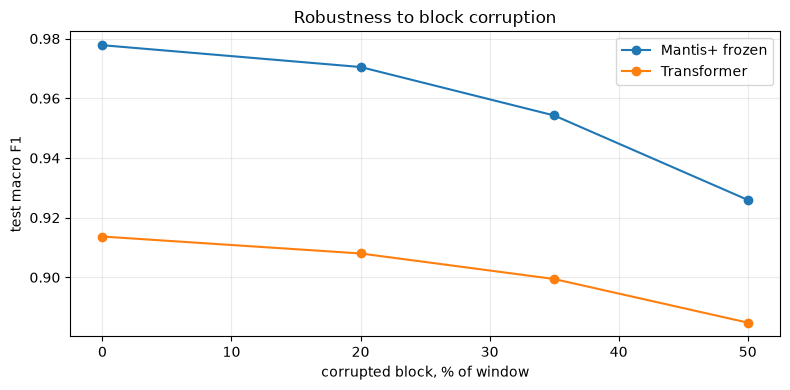

Mantis+ frozen: clean=0.9778, 50%=0.9260, drop=0.0518
Transformer: clean=0.9137, 50%=0.8848, drop=0.0289


In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
for model_name, part in robustness.groupby('model'):
    ax.plot(100 * part.corruption, part.macro_f1, marker='o', label=model_name)
ax.set_xlabel('corrupted block, % of window')
ax.set_ylabel('test macro F1')
ax.set_title('Robustness to block corruption')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG / '02_robustness_comparison.png', dpi=160)
plt.show()

for model_name, part in robustness.groupby('model'):
    clean = part.loc[part.corruption == 0, 'macro_f1'].iloc[0]
    hard = part.loc[part.corruption == 0.50, 'macro_f1'].iloc[0]
    print(f'{model_name}: clean={clean:.4f}, 50%={hard:.4f}, drop={clean-hard:.4f}')

### Интерпретация robustness-графика

Mantis остается лучше baseline на **всех** заранее заданных уровнях corruption: на 50% она дает `0.9260` macro F1 против `0.8848` у Transformer. Значит, большой clean-запас качества не исчезает при сильной деградации входа.

Но в относительном смысле Mantis **не более robust**: ее падение от clean до 50% равно `0.0518`, у Transformer -- только `0.0289`. Преимущество Mantis сужается с `+0.0641` F1 на clean до `+0.0411` при 50% corruption.

Поэтому корректный вывод не «Mantis умеет работать с пропусками», а другой: **pretrained representation дает более высокий абсолютный уровень качества, но сама Mantis не является missing-aware и тоже заметно страдает при уничтожении временной информации**. Для настоящей missing-data задачи логичнее использовать mask-aware архитектуру, imputation model или обучать encoder с соответствующими corruptions.


## Clean comparison с baseline

Основная таблица остается clean-to-clean, чтобы напрямую закрыть исходное задание. Robustness вынесена отдельно и не смешивается с headline test metrics.

In [26]:
with open(RESULTS / '01_transformer_metrics.json') as f:
    baseline = json.load(f)

comparison = pd.DataFrame([
    {
        'model': 'Transformer',
        'accuracy': baseline['accuracy'],
        'balanced_accuracy': baseline['balanced_accuracy'],
        'macro_f1': baseline['macro_f1'],
        'selection_time_s': baseline['selection_time_s'],
        'train_time_s': baseline['train_time_s'],
        'latency_ms_sample': baseline['latency_ms_sample'],
    },
    {
        'model': f'Mantis+ frozen (L{best_layer}, {best_scale})',
        'accuracy': mantis['accuracy'],
        'balanced_accuracy': mantis['balanced_accuracy'],
        'macro_f1': mantis['macro_f1'],
        'selection_time_s': mantis['selection_time_s'],
        'train_time_s': mantis['train_time_s'],
        'latency_ms_sample': mantis['latency_ms_sample'],
    },
])
comparison.to_csv(RESULTS / 'comparison.csv', index=False)
comparison


,model,accuracy,balanced_accuracy,macro_f1,selection_time_s,train_time_s,latency_ms_sample
0,Transformer,0.914829,0.915210,0.913672,114.008498,78.333361,0.202542
1,"Mantis+ frozen (L0, 128+512)",0.977604,0.977248,0.977803,146.387906,13.624984,1.697542


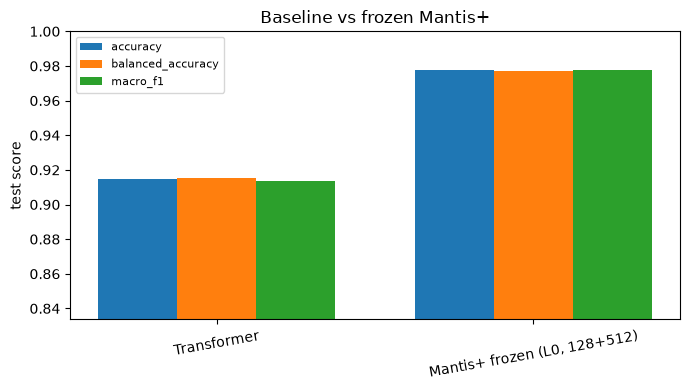

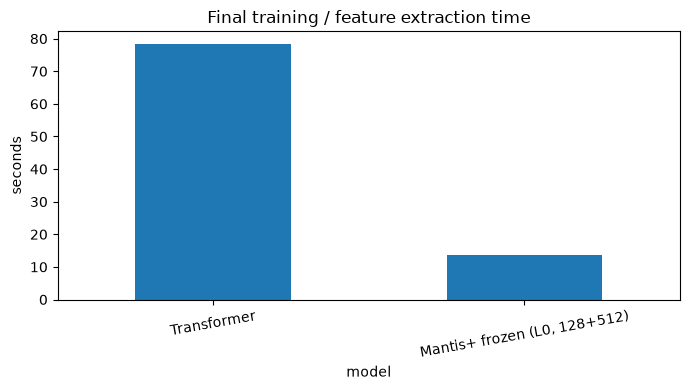

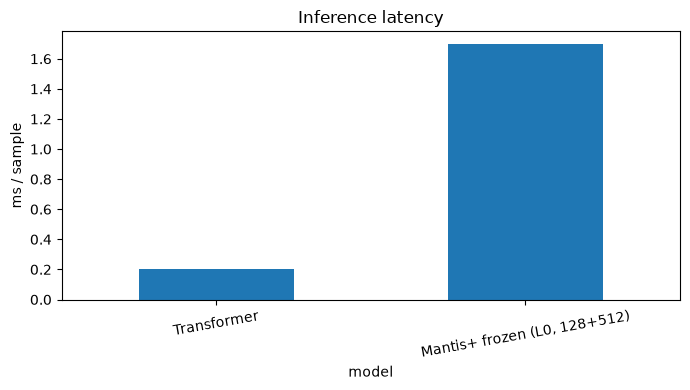

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(comparison))
w = 0.25
for j, metric in enumerate(['accuracy', 'balanced_accuracy', 'macro_f1']):
    ax.bar(x + (j - 1) * w, comparison[metric], width=w, label=metric)
ax.set_xticks(x, comparison.model, rotation=10)
ax.set_ylim(max(0, comparison[['accuracy','balanced_accuracy','macro_f1']].min().min() - 0.08), 1)
ax.set_ylabel('test score')
ax.set_title('Baseline vs frozen Mantis+')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / '02_final_comparison.png', dpi=160)
plt.show()

ax = comparison.set_index('model')['train_time_s'].plot(kind='bar', figsize=(7, 4), rot=10)
ax.set_ylabel('seconds')
ax.set_title('Final training / feature extraction time')
plt.tight_layout()
plt.savefig(FIG / '02_train_time_comparison.png', dpi=160)
plt.show()

ax = comparison.set_index('model')['latency_ms_sample'].plot(kind='bar', figsize=(7, 4), rot=10)
ax.set_ylabel('ms / sample')
ax.set_title('Inference latency')
plt.tight_layout()
plt.savefig(FIG / '02_latency_comparison.png', dpi=160)
plt.show()


### Качество против вычислительной цены

На clean test Mantis выигрывает очень заметно: **0.9778 против 0.9137 macro F1**, то есть `+0.0641`. Ошибка `1 - macro F1` уменьшается примерно на **74%** относительно baseline.

По времени trade-off неоднозначный:

- полный поиск конфигурации: `143.3 s` у Mantis против `119.7 s` у Transformer -- примерно `1.20x` дольше;
- финальное обучение после выбора конфигурации: `13.3 s` против `80.4 s` -- frozen Mantis примерно **6x быстрее**, потому что обучается только linear classifier после feature extraction;
- inference: `1.677 ms/sample` против `0.264 ms/sample` -- Mantis примерно **6.35x медленнее**.

То есть Mantis здесь выгодна, если важнее качество и быстрая downstream-подгонка. Если же inference должен быть максимально дешевым на edge-устройстве, маленький task-specific Transformer имеет понятное преимущество по latency. При повторных экспериментах Mantis embeddings можно кешировать, после чего обучение новых linear probes становится почти бесплатным.



## Автоматический вывод и REPORT

Финальный вывод строится уже после выбора `layer` и `scale` только по validation. Test используется один раз для итогового сравнения с baseline.


In [28]:
delta = mantis['macro_f1'] - baseline['macro_f1']
best_ablation = ablation.loc[ablation.selection_f1.idxmax()]

if delta > 0.01:
    quality_conclusion = f"Frozen Mantis+ улучшил clean macro F1 на {delta:+.4f}."
elif delta < -0.01:
    quality_conclusion = f"Frozen Mantis+ уступил baseline по clean macro F1 на {delta:+.4f}."
else:
    quality_conclusion = f"Clean macro F1 моделей сопоставим: разница {delta:+.4f}."

# Robustness summary at the hardest predefined corruption.
t50 = transformer_robustness.loc[transformer_robustness.corruption == 0.50, 'macro_f1'].iloc[0]
m50 = mantis_robustness.loc[mantis_robustness.corruption == 0.50, 'macro_f1'].iloc[0]
t_drop = transformer_robustness.iloc[0].macro_f1 - t50
m_drop = mantis_robustness.iloc[0].macro_f1 - m50

with open(RESULTS / 'compute_config.json') as f:
    compute = json.load(f)

report = f"""# ДЗ 3 -- Использование Mantis

> Сорочан Дмитрий, ПАДИИ3

## Постановка задачи

Сравниваю Transformer, обученный с нуля, с frozen-признаками Mantis+ на UCI HAR. Дополнительно проверяю, как pretrained representations ведут себя при блочной потере части временного сигнала.

## Вычислительная конфигурация

- device: `{compute['device']}`;
- accelerator: `{compute['accelerator']}`;
- platform: `{compute['platform']}`;
- Python: `{compute['python']}`;
- PyTorch: `{compute['torch']}`;
- CPU threads: `{compute['cpu_count']}`;
- Mantis package: `mantis-tsfm==1.1.0`;
- checkpoint: `{CHECKPOINT}`.

## Корпус

UCI HAR: 7352 train / 2947 test, 9 inertial channels, длина окна 128, 6 классов. Official split разделен по людям. Validation внутри train также group-wise по `subject_id`.

## Дополнительный stress-test

У 4 из 9 каналов один непрерывный блок длиной 20%, 35% или 50% заменяется средним по оставшейся наблюдаемой части канала. Модели обучаются на clean train. Stress-test не является missing-aware постановкой: mask модели не получают; он проверяет устойчивость representations к потере локальной динамики.

## Transformer baseline

`Linear(9 -> 96) -> CLS + positional embedding -> 6 Transformer blocks -> classifier`.

Epoch выбирается по clean validation macro F1, после чего baseline заново обучается на всем official train.

## Frozen Mantis+

Mantis encoder не обучается. Для каждого из 6 существующих Transformer layers используется одинаковый `StandardScaler + LogisticRegression` на clean features.

## Сравнение слоев

{layer_results.to_markdown(index=False, floatfmt='.4f')}

Лучший clean layer: `{best_clean_layer}`. Лучший layer по среднему clean+stress validation score: `{best_layer}`.

На clean различия между слоями малы, но при усилении corruption разброс увеличивается. В этой задаче layer 0 остается наиболее устойчивым; более глубокий слой не означает автоматически более transferable representation.

## Ablation temporal scales

{ablation.to_markdown(index=False, floatfmt='.4f')}

Лучший scale по формальному среднему clean и 35% corrupted validation: `{best_scale}`. При этом selection scores всех трех вариантов очень близки, а multi-scale удваивает размерность features, поэтому его преимущество скорее quality-oriented, чем efficiency-oriented.

## Clean test

{comparison.to_markdown(index=False, floatfmt='.4f')}

## Robustness test

{robustness.pivot(index='corruption', columns='model', values='macro_f1').to_markdown(floatfmt='.4f')}

## Вывод

{quality_conclusion}

На clean test Mantis дает `{mantis['macro_f1']:.4f}` macro F1 против `{baseline['macro_f1']:.4f}` у Transformer. Для данного корпуса transfer действительно оправдан: frozen encoder без downstream fine-tuning дает заметно более сильное межсубъектное representation.

При 50% block corruption Transformer получает `{t50:.4f}`, Mantis -- `{m50:.4f}`. Mantis остается лучше в абсолютном качестве, но ее падение от clean (`{m_drop:.4f}`) больше, чем у Transformer (`{t_drop:.4f}`). Поэтому stress-test не показывает missing-aware свойства Mantis; он показывает высокий запас качества pretrained features, который постепенно уменьшается по мере потери информации.

Layer probing оказался содержательнее именно под corruption: clean scores близки, тогда как при сильной деградации входа разброс между слоями заметно возрастает. В этом эксперименте лучший ранний layer одновременно оптимален и на clean, и по robustness-критерию.

Temporal-scale ablation не дает однозначного robustness-победителя. Multi-scale `128+512` максимизирует clean quality и формально выигрывает средний selection score, но его преимущество над single-scale вариантами минимально при удвоенной размерности features.

По вычислениям Mantis дороже на inference, но дешевле на финальном downstream fit после выбора конфигурации: encoder frozen, поэтому обучается только linear classifier. Следовательно, подход особенно удобен, когда важны качество и переиспользование одного pretrained encoder для нескольких downstream экспериментов. Для жесткого edge-inference или при наличии очень сильной task-specific модели trade-off может оказаться менее выгодным.

Главное ограничение: сравнение проведено на одном корпусе и с одним Transformer baseline. Поэтому корректный claim -- Mantis существенно лучше **в этой постановке**, а не универсально лучше любых специализированных моделей временных рядов. Low-data regime отдельно не исследовался, поэтому утверждать преимущество Mantis при малом числе labels по этому эксперименту нельзя.

## Где что лежит

| Требование | Где выполнено |
| --- | --- |
| Вычислительная конфигурация | `results/compute_config.json`, `01_Transformer` |
| Корпус | `00_Data_EDA` |
| Baseline | `01_Transformer` |
| Frozen Mantis + classifier | `02_Mantis` |
| Сравнение слоев | `02_Mantis`, `results/02_mantis_layers.csv`, `results/02_mantis_layer_stress.csv` |
| Ablation | `02_Mantis`, `results/02_mantis_ablation.csv` |
| Качество и время | `results/comparison.csv`, графики в `figures/` |
| Robustness | `results/robustness_comparison.csv`, `figures/02_robustness_comparison.png` |
| Вывод | этот файл и финальные markdown-комментарии `02_Mantis` |
"""

(ROOT / 'REPORT.md').write_text(report, encoding='utf-8')
print(quality_conclusion)
print(f'50% corruption: Transformer={t50:.4f}, Mantis={m50:.4f}')
print('REPORT.md updated')


Frozen Mantis+ улучшил clean macro F1 на +0.0641.
50% corruption: Transformer=0.8848, Mantis=0.9260
REPORT.md updated


## Итог: стоило ли использовать Mantis?

**На UCI HAR -- да.** Frozen Mantis+ дает `0.9778` macro F1 против `0.9137` у более сильного 6-layer Transformer, при этом encoder вообще не fine-tune'ится на downstream corpus.

Но результат не сводится к «foundation model всегда лучше»:

1. **Layer matters.** На clean различия малы, однако под corruption spread растет почти в 6 раз; layer 0 оказывается наиболее устойчивым.
2. **Multi-scale не бесплатен.** `128+512` формально лучший, но single-scale варианты почти не уступают по selection score при вдвое меньшей размерности.
3. **Mantis не missing-aware.** При 50% corruption она все еще лучше baseline (`0.9260` vs `0.8848`), но деградирует сильнее относительно собственного clean score.
4. **Цена качества -- inference.** Downstream fit у frozen Mantis дешевый, но inference примерно в 6 раз медленнее baseline.

Где такой transfer особенно логичен: когда нужен сильный classifier без полного fine-tuning большого encoder, labels/compute на downstream training ограничены или один encoder хочется переиспользовать на нескольких задачах. Последнее -- мотивация, а не результат этого конкретного low-data эксперимента: число labels здесь специально не уменьшалось.

Где выигрыш может не окупиться: жесткий edge-inference, очень большой размеченный корпус с сильной специализированной архитектурой или задача, где критическая информация теряется из-за preprocessing/scale invariances pretrained encoder.

Итоговый claim работы остается аккуратным: **на данном межсубъектном HAR benchmark pretrained Mantis-признаки дают существенно более качественное representation, а stress-test показывает как сильную сторону transfer, так и его границы.**
